In [1]:
import numpy as np

with open("data_files/belgian_temp.npy", "rb") as fh:
    df_arr = np.load(fh)
    year_range_arr = np.load(fh)
    station_name_arr = np.load(fh)
    files_arr = np.load(fh)

1. Generate an array with for every year and month the average temperature observed in all stations.
2. How many months in the whole period had an average temperature below 0?
3. Which were on average the warmest and coldest year in Belgium?
4. When was the biggest temperature difference observed between consecutive months in Belgium?
5. Use a sliding window to compute the average temperature per 12 months

In [2]:
# 1. Generate an array with for every year and month the average temperature observed in all stations.
df_avg = np.nanmean(df_arr, axis=0)  #shape (145, 12)
df_flatten = df_avg.reshape(-1,)    #shape (1740,)

/var/folders/ln/gbs9zy0n4fs374gdtp6rp1xw0000gn/T/ipykernel_68093/3728817197.py:2: RuntimeWarning: Mean of empty slice
  df_avg = np.nanmean(df_arr, axis=0)  #shape (145, 12)


In [5]:
# 2. How many months in the whole period had an average temperature below 0?
avg_temp_below_0 = np.sum(df_avg < 0)
avg_temp_below_0

np.int64(290)

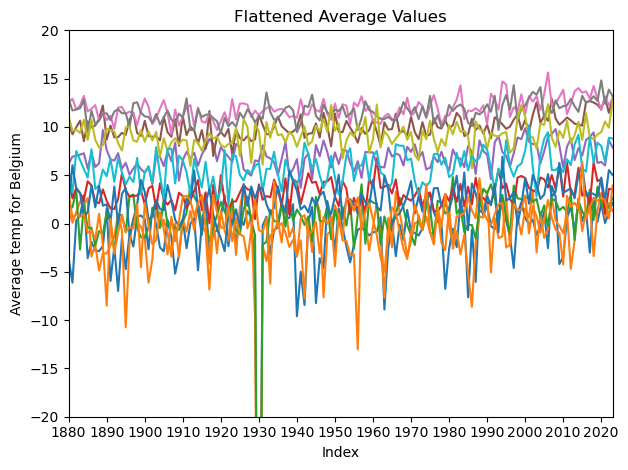

In [32]:

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1)
new_arr = np.pad(year_range_arr, (0, 1), mode='constant', constant_values=2024)

ax.plot(new_arr, df_avg)

# Improve x-axis ticks (show every 10 years)
ax.set_xticks(np.arange(1880, 2024, 10))  
ax.set_xlim(1880, 2023)  # Explicitly set range

# Add labels if needed
ax.set_xlabel("Index")
ax.set_ylabel("Average temp for Belgium")
ax.set_title("Flattened Average Values")

ax.set_ylim(-20,20)

# Display the plot
plt.tight_layout()
plt.show()